In [5]:
import pandas as pd

df = pd.read_csv("athlete_events.csv")

df.head(20)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
5,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",NaN
6,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,NaN
7,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",NaN
8,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,NaN
9,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,"Speed Skating Women's 1,000 metres",NaN


In [6]:
df.shape

(271116, 15)

In [7]:
df.columns

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='object')

In [8]:
df.isnull().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

In [9]:
df.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [11]:
df = df.drop_duplicates()

In [13]:
df = df[['Name','Sex','Age','Team','NOC','Year','Season','Sport','Event','Medal']]

In [14]:
df = df[df['Season'] == 'Summer']

In [15]:
df["Medal_Won"] = df["Medal"].notna().astype(int)

In [18]:
df.head(20)

,Name,Sex,Age,Team,NOC,Year,Season,Sport,Event,Medal,Medal_Won
0,A Dijiang,M,24.0,China,CHN,1992,Summer,Basketball,Basketball Men's Basketball,NaN,0
1,A Lamusi,M,23.0,China,CHN,2012,Summer,Judo,Judo Men's Extra-Lightweight,NaN,0
2,Gunnar Nielsen Aaby,M,24.0,Denmark,DEN,1920,Summer,Football,Football Men's Football,NaN,0
3,Edgar Lindenau Aabye,M,34.0,Denmark/Sweden,DEN,1900,Summer,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,1
26,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,Netherlands,NED,1932,Summer,Athletics,Athletics Women's 100 metres,NaN,0
27,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,Netherlands,NED,1932,Summer,Athletics,Athletics Women's 4 x 100 metres Relay,NaN,0
29,"Einar Ferdinand ""Einari"" Aalto",M,26.0,Finland,FIN,1952,Summer,Swimming,Swimming Men's 400 metres Freestyle,NaN,0
31,Jyri Tapani Aalto,M,31.0,Finland,FIN,2000,Summer,Badminton,Badminton Men's Singles,NaN,0
32,Minna Maarit Aalto,F,30.0,Finland,FIN,1996,Summer,Sailing,Sailing Women's Windsurfer,NaN,0
33,Minna Maarit Aalto,F,34.0,Finland,FIN,2000,Summer,Sailing,Sailing Women's Windsurfer,NaN,0


In [19]:
df.shape

(221167, 11)

In [20]:
df.isnull().sum()

Name              0
Sex               0
Age            9030
Team              0
NOC               0
Year              0
Season            0
Sport             0
Event             0
Medal        187090
Medal_Won         0
dtype: int64

In [21]:
df["Medal_Won"].value_counts()

Medal_Won
0    187090
1     34077
Name: count, dtype: int64

In [22]:
country_medals = df.groupby("Team")["Medal_Won"].sum().sort_values(ascending=False)

country_medals.head(10)

Team
United States    4686
Soviet Union     2061
Germany          1687
Great Britain    1598
France           1408
Italy            1384
Australia        1290
Hungary          1123
Sweden           1006
Russia            894
Name: Medal_Won, dtype: int64

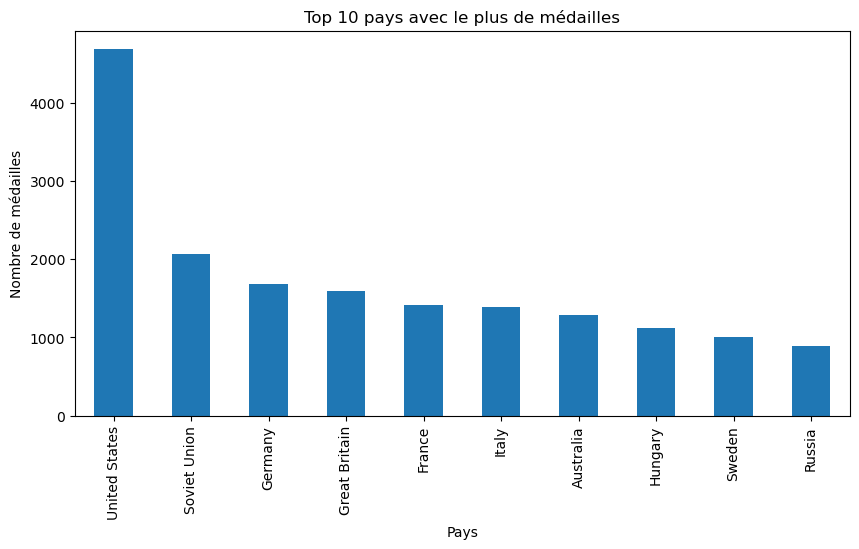

In [23]:
import matplotlib.pyplot as plt

country_medals.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top 10 pays avec le plus de médailles")
plt.xlabel("Pays")
plt.ylabel("Nombre de médailles")

plt.show()